# On-Chain Fundamentals: DeFi TVL as Alternative Data

**Chapter 4: Fundamental and Alternative Data**
**Docker image**: `ml4t`
**Section Reference**: Section 4.4 (Understanding Alternative Data)

## Purpose

A public blockchain records every transaction, so a quantity that would be a trade secret in
any other market is simply readable: how much capital is deposited in each lending pool,
exchange and vault. Summed across the protocols on a chain, that is **total value locked**,
and it is the closest thing decentralized finance has to a fundamental.

It is also a good specimen for the question this section of the chapter is about, which is not
"what does this dataset measure" but "is it worth integrating". This notebook takes the
obvious hypothesis - that capital flowing into DeFi precedes a rising ether price - and tries
to measure it. Most of the work turns out to be establishing how little the available data can
say, which is the usual outcome of an honest alternative-data evaluation and the reason the
evaluation happens before the integration.

## Learning Objectives

After completing this notebook, you will be able to:

- Define total value locked and say what it does and does not measure.
- Load a chain-level TVL history and a matched price series, and identify which of the two
  bounds the window you can study.
- Show a composition breakdown against the true total rather than against the subset you
  selected.
- Turn a level into momentum and regime features, and state the window each is measured over.
- Test whether a signal predicts a forward return, and correct the test for the overlap that
  forward returns create.
- Count the independent observations behind a result, and decide from that count whether the
  result can be acted on.

## Prerequisites

Both feeds are free and are cached locally by one downloader, so the notebook does no
network access:

```bash
python data/crypto/onchain/download.py --dataset defillama
python data/crypto/onchain/download.py --dataset coingecko
```

## Cross-References

- **Related**: [`07_macro_data_alignment`](07_macro_data_alignment.ipynb) (the same publication-timing discipline on macro series)
- **Downstream**: [`11_defi_tvl_evaluation`](11_defi_tvl_evaluation.ipynb) (the full due-diligence framework applied to this dataset)

## Key Concepts

- **Total value locked (TVL)**: the dollar value of the crypto assets deposited in a chain's
  decentralized finance protocols, valued at current prices.
- **Chain TVL**: that figure for one blockchain. **Protocol TVL** is the same for one
  application.
- **Forward return**: the return realized over a stated window *after* the date a signal is
  observed, which is the quantity a signal has to predict to be worth anything.
- **Overlapping windows**: consecutive forward returns computed over a window longer than the
  sampling interval share most of their days, so consecutive observations are not independent
  draws and a test that assumes they are overstates its own significance.

In [1]:
"""On-Chain Fundamentals: DeFi TVL as Alternative Data - source and analyze DeFi TVL for crypto trading signals."""

import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import polars as pl
import statsmodels.api as sm
from plotly.subplots import make_subplots

from data import load_coingecko_ohlcv, load_defillama_chain_tvl
from utils.style import COLORS, show_plotly_with_alt

The forward horizon is the setting that decides what is being tested. Thirty days asks whether
TVL predicts a month of ether returns, which is the horizon the conventional story is told at;
it is also what creates the overlap Part 6 has to correct for, since the series is daily.

In [2]:
CHAINS = ["Ethereum", "Solana", "BSC", "Arbitrum"]  # the four largest by TVL
FORWARD_DAYS = 30  # the return horizon the signal is tested against
MOMENTUM_DAYS = 30  # the window TVL growth is measured over
ZSCORE_DAYS = 90  # the window a TVL level is judged unusual against
REGIME_Z = 1.0  # standard deviations from the mean that separate the three regimes
RECENT_DAYS = 30  # the trailing window the composition breakdown averages over

## 1. What total value locked measures

When someone deposits ether into a lending protocol, the deposit sits in a smart contract
whose balance anyone can read. TVL is the sum of those balances across a chain's protocols,
converted to dollars at current prices.

Two properties follow from that definition and both matter for how the number can be read.
It is a **stock**, not a flow: it does not distinguish new capital arriving from existing
deposits appreciating, so a chain whose TVL doubled while its native token doubled has
attracted nothing. And it is **denominated in dollars while being held in crypto**, so it
falls when prices fall whether or not anyone withdrew.

The conventional readings below are the ones a data vendor's pitch deck offers. They are
hypotheses, and Part 6 tests one of them.

| Pattern | Conventional reading |
|---------|----------------------|
| TVL growing faster than the ether price | Capital arriving rather than deposits appreciating |
| TVL falling while the price holds | Capital leaving; risk appetite falling |
| A TVL spike | A new protocol or a yield opportunity pulling deposits in |
| A TVL collapse | An exploit, a cascade of liquidations, or a general panic |

## 2. The TVL history

DeFi Llama publishes the series free and it goes back to the start of the sector. Seeing its
full length first matters, because the joined panel later in this notebook is a small fraction
of it and the reason is worth knowing before the results are read.

In [3]:
total_tvl = (
    load_defillama_chain_tvl("total").sort("timestamp").with_columns(tvl_bn=pl.col("tvl_usd") / 1e9)
)
print(f"Observations: {len(total_tvl):,}")
print(f"History: {total_tvl['timestamp'].min()} to {total_tvl['timestamp'].max()}")
print(f"Highest level reached: ${total_tvl['tvl_bn'].max():.0f}bn")

Observations: 3,139
History: 2017-09-27 to 2026-05-01
Highest level reached: $177bn


The cell below prints the landmarks the figure turns on. Each one after the peak exists only if
the snapshot runs past the one before it: the downloader fetches history up to today, so a
refresh landing on a new all-time high leaves nothing after the peak, and one landing on the
post-peak minimum leaves nothing after the trough. Both are ordinary snapshots rather than
errors, so the list is built conditionally.

In [4]:
_peak = total_tvl.filter(pl.col("tvl_bn") == pl.col("tvl_bn").max())
_peak_bn, _peak_at = _peak["tvl_bn"][0], _peak["timestamp"][0]
_landmarks = [("peak", _peak_bn, _peak_at)]
_post = total_tvl.filter(pl.col("timestamp") > _peak_at)
if len(_post):
    _trough = _post.filter(pl.col("tvl_bn") == pl.col("tvl_bn").min())
    _landmarks.append(("post-peak trough", _trough["tvl_bn"][0], _trough["timestamp"][0]))
    _rec = _post.filter(pl.col("timestamp") > _trough["timestamp"][0])
    if len(_rec):
        _high = _rec.filter(pl.col("tvl_bn") == _rec["tvl_bn"].max())
        _landmarks.append(("recovery high", _high["tvl_bn"][0], _high["timestamp"][0]))
_landmarks.append(("latest", total_tvl["tvl_bn"][-1], total_tvl["timestamp"][-1]))
for _label, _bn, _at in _landmarks:
    print(f"  {_label:<18} ${_bn:>6.1f}bn on {_at}   {_bn / _peak_bn:>5.0%} of peak")
total_tvl.tail(3)

  peak               $ 177.5bn on 2021-12-02    100% of peak
  post-peak trough   $  36.0bn on 2023-10-13     20% of peak
  recovery high      $ 171.2bn on 2025-10-07     96% of peak
  latest             $  84.6bn on 2026-05-01     48% of peak


timestamp,tvl_usd,tvl_bn
date,i64,f64
2026-04-29,83282116410,83.282116
2026-04-30,83484152685,83.484153
2026-05-01,84621565953,84.621566


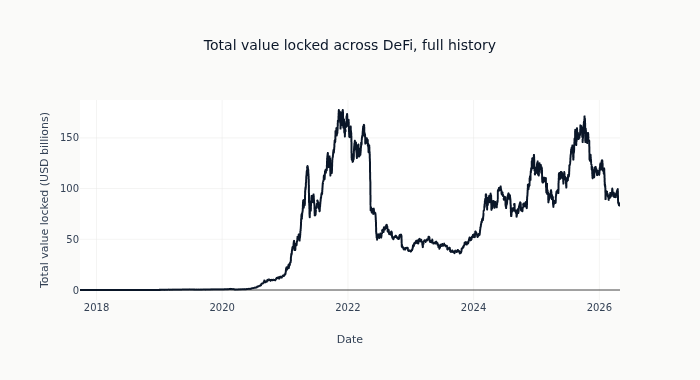

In [5]:
fig = px.line(
    total_tvl.to_pandas(),
    x="timestamp",
    y="tvl_bn",
    title="Total value locked across DeFi, full history",
    labels={"timestamp": "Date", "tvl_bn": "Total value locked (USD billions)"},
    color_discrete_sequence=[COLORS["blue"]],
)
fig.update_layout(height=380)
show_plotly_with_alt(
    fig,
    "Line chart of total value locked across DeFi over the full published history, in billions "
    "of dollars, against a date axis.",
)

### Which chains hold it

Chain-level series let the total be decomposed. The chains loaded here are the largest, and the
breakdown below measures them against the **total** rather than against each other, so that
the share held by everything else is visible rather than assumed away.

The residual bar is an aggregate over every chain not loaded separately, so it is reported
apart from the named chains rather than ranked among them as if it were one. Whenever the
chains loaded hold less than half the total between them the residual is the longest bar, and
ranking it alongside them would report an aggregate over hundreds of chains as though one
chain held the sector.

In [6]:
chain_tvl = {}
for chain in CHAINS:
    series = load_defillama_chain_tvl(chain).sort("timestamp")
    chain_tvl[chain] = series
    print(f"{chain}: {len(series):,} observations from {series['timestamp'].min()}")

Ethereum: 3,139 observations from 2017-09-27
Solana: 1,871 observations from 2021-03-18
BSC: 2,009 observations from 2020-10-31
Arbitrum: 1,732 observations from 2021-06-04


In [7]:
recent_total = float(total_tvl.tail(RECENT_DAYS)["tvl_bn"].mean())
composition = pl.DataFrame(
    [
        {
            "chain": chain,
            "tvl_bn": float(series.tail(RECENT_DAYS)["tvl_usd"].mean()) / 1e9,
        }
        for chain, series in chain_tvl.items()
    ]
).sort("tvl_bn", descending=True)
composition = pl.concat(
    [
        composition,
        pl.DataFrame(
            {"chain": ["All other chains"], "tvl_bn": [recent_total - composition["tvl_bn"].sum()]}
        ),
    ]
).with_columns(share=pl.col("tvl_bn") / recent_total)

# The residual is reported apart from the named chains rather than ranked among them.
_named = composition.head(composition.height - 1).sort("share", descending=True)
_residual = composition.row(-1, named=True)
_top = _named.row(0, named=True)
print(f"Largest chain loaded:   {_top['chain']}, {_top['share']:.1%} of the total")
print(f"Other chains loaded:    {_named['share'].sum() - _top['share']:.1%} of the total")
print(f"Not loaded separately:  {_residual['share']:.1%} of the total, in one residual bar")
print(
    f"The largest chain loaded holds "
    f"{'more' if _top['share'] > 1 - _top['share'] else 'less'} than every other bar combined"
)
composition

Largest chain loaded:   Ethereum, 55.8% of the total
Other chains loaded:    14.2% of the total
Not loaded separately:  30.0% of the total, in one residual bar
The largest chain loaded holds more than every other bar combined


chain,tvl_bn,share
str,f64,f64
"""Ethereum""",50.658853,0.557854
"""Solana""",5.614813,0.06183
"""BSC""",5.469839,0.060234
"""Arbitrum""",1.846736,0.020336
"""All other chains""",27.21997,0.299746


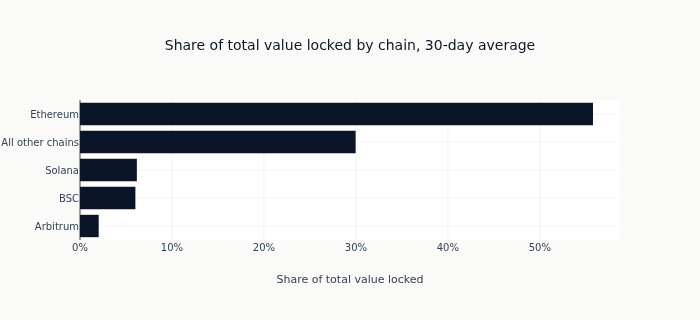

In [8]:
fig = px.bar(
    composition.to_pandas(),
    x="share",
    y="chain",
    orientation="h",
    title=f"Share of total value locked by chain, {RECENT_DAYS}-day average",
    labels={"share": "Share of total value locked", "chain": ""},
    color_discrete_sequence=[COLORS["blue"]],
)
fig.update_layout(height=320, xaxis_tickformat=".0%", yaxis=dict(categoryorder="total ascending"))
show_plotly_with_alt(
    fig,
    "Horizontal bar chart of each chain's share of total value locked, averaged over the "
    "trailing window, with one bar per chain loaded and a residual bar for the chains not "
    "loaded separately. Shares are measured against the published total.",
)

The shares printed above are what the breakdown is for. Measuring against the published total
rather than against each other keeps the share held by chains outside the selection visible,
and the residual bar is how much of the sector the selection leaves out. Where one chain holds
more than every other bar combined, a "DeFi total" is mostly that chain's series, and a result
about the total is not a result about the sector.

## 3. The price series, and what bounds the study

Testing whether TVL predicts returns needs a price. CoinGecko's free tier serves the trailing
365 days and no more, so the joined panel is one year long however far back the TVL series
reaches. That is not a detail: it is the constraint that decides what this notebook can
conclude, and Part 6 comes back to it.

The free tier also appends a live intraday snapshot on top of the current day's midnight bar,
so the last calendar day can arrive twice. Collapsing to the most recent row per day is done
before anything joins to it.

In [9]:
eth = load_coingecko_ohlcv("ethereum").unique(subset="timestamp", keep="last", maintain_order=True)
print(f"Price observations: {len(eth):,}")
print(f"Window: {eth['timestamp'].min()} to {eth['timestamp'].max()}")
print(
    f"TVL history that window discards: {(eth['timestamp'].min() - total_tvl['timestamp'].min()).days:,} days"
)

Price observations: 365
Window: 2025-05-02 to 2026-05-01
TVL history that window discards: 2,774 days


In [10]:
panel = (
    total_tvl.join(
        eth.rename({"price_usd": "eth_price", "volume_usd": "eth_volume"}),
        on="timestamp",
        how="inner",
    )
    .sort("timestamp")
    .select("timestamp", "tvl_bn", "eth_price", "eth_volume")
)
print(
    f"Joined panel: {len(panel):,} rows, {panel['timestamp'].min()} to {panel['timestamp'].max()}"
)
panel.tail(3)

Joined panel: 365 rows, 2025-05-02 to 2026-05-01


timestamp,tvl_bn,eth_price,eth_volume
date,f64,f64,f64
2026-04-29,83.282116,2288.044927,1.2067e10
2026-04-30,83.484153,2253.458358,1.9379e10
2026-05-01,84.621566,2294.157168,1.2321e10


In [11]:
_level_corr = float(panel.select(pl.corr("tvl_bn", "eth_price")).item())
print(f"Pearson correlation of the two levels over the joined window: {_level_corr:.2f}")

Pearson correlation of the two levels over the joined window: 0.98


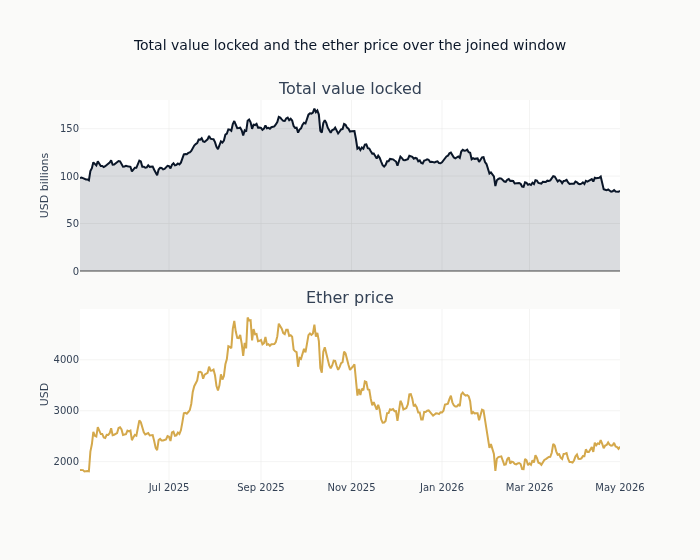

In [12]:
fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.1,
    subplot_titles=("Total value locked", "Ether price"),
)
fig.add_trace(
    go.Scatter(
        x=panel["timestamp"],
        y=panel["tvl_bn"],
        line=dict(color=COLORS["blue"]),
        fill="tozeroy",
        fillcolor="rgba(10, 22, 40, 0.15)",  # translucent COLORS["blue"]
        name="TVL",
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=panel["timestamp"], y=panel["eth_price"], line=dict(color=COLORS["amber"]), name="ETH"
    ),
    row=2,
    col=1,
)
fig.update_yaxes(title_text="USD billions", row=1, col=1)
fig.update_yaxes(title_text="USD", row=2, col=1)
fig.update_layout(
    height=560,
    showlegend=False,
    title="Total value locked and the ether price over the joined window",
)
show_plotly_with_alt(
    fig,
    "Two stacked panels sharing one date axis over the joined panel's window: total value "
    "locked in billions of dollars above, the ether price in dollars below.",
)

The correlation printed above is there because of what TVL is. It is a dollar value of crypto
holdings, so it follows the price of those holdings by construction rather than by any
relationship worth testing. A test of whether TVL predicts the price therefore has to work with
a quantity that is not the price again, which is why the features below are growth rates and
z-scores rather than levels.

## 4. Features

Three quantities, each with the window it is measured over stated in its name. Growth over the
momentum window; the level as a z-score against a longer window, which is what makes "high" or
"low" mean something; and the regime label that z-score falls into.

In [13]:
features = panel.with_columns(
    tvl_growth=pl.col("tvl_bn").pct_change(MOMENTUM_DAYS),
    eth_return=pl.col("eth_price").pct_change(MOMENTUM_DAYS),
    tvl_zscore=(pl.col("tvl_bn") - pl.col("tvl_bn").rolling_mean(ZSCORE_DAYS))
    / pl.col("tvl_bn").rolling_std(ZSCORE_DAYS),
).with_columns(
    # A row without a full z-score window is unclassified rather than neutral: pooling the
    # warm-up into the middle band would put a hundred days of "no measurement" into a bucket
    # the analysis then reads as a measurement.
    tvl_regime=pl.when(pl.col("tvl_zscore").is_null())
    .then(pl.lit(None, dtype=pl.String))
    .when(pl.col("tvl_zscore") > REGIME_Z)
    .then(pl.lit("expansion"))
    .when(pl.col("tvl_zscore") < -REGIME_Z)
    .then(pl.lit("contraction"))
    .otherwise(pl.lit("neutral"))
)
features.select("timestamp", "tvl_bn", "tvl_growth", "tvl_zscore", "tvl_regime").tail(5)

timestamp,tvl_bn,tvl_growth,tvl_zscore,tvl_regime
date,f64,f64,f64,str
2026-04-27,85.237201,-0.070388,-1.529976,"""contraction"""
2026-04-28,83.714614,-0.089589,-1.843052,"""contraction"""
2026-04-29,83.282116,-0.094527,-2.033559,"""contraction"""
2026-04-30,83.484153,-0.093046,-2.069035,"""contraction"""
2026-05-01,84.621566,-0.102453,-1.904989,"""contraction"""


## 5. The forward return

The quantity a signal has to predict is the return *after* it is observed. It is computed
directly from the price at the two ends of the forward window rather than by shifting the
trailing return: the trailing return is measured over the momentum window, and shifting it by
the forward horizon only coincides with the forward return while those two settings happen to
be equal.

In [14]:
tested = features.with_columns(
    forward_return=pl.col("eth_price").shift(-FORWARD_DAYS) / pl.col("eth_price") - 1
).drop_nulls(["tvl_growth", "forward_return"])

print(f"Rows with both a signal and a forward return: {len(tested):,}")
print(f"Signal dates: {tested['timestamp'].min()} to {tested['timestamp'].max()}")

Rows with both a signal and a forward return: 305
Signal dates: 2025-06-01 to 2026-04-01


## 6. Testing the hypothesis, and counting the evidence

The regime table is the obvious first cut: average the forward return within each regime and
compare. It is also where an alternative-data evaluation most often goes wrong, because the
table looks like evidence and is not yet.

In [15]:
by_regime = (
    tested.drop_nulls("tvl_regime")
    .group_by("tvl_regime")
    .agg(
        pl.len().alias("days"),
        pl.col("forward_return").mean().alias("mean_forward_return"),
        pl.col("forward_return").std().alias("std_forward_return"),
    )
    .sort("mean_forward_return", descending=True)
)
by_regime

tvl_regime,days,mean_forward_return,std_forward_return
str,u32,f64,f64
"""contraction""",97,0.012603,0.082799
"""expansion""",64,-0.023619,0.133068
"""neutral""",85,-0.163669,0.179557


### What those means are worth

A mean needs a standard error, and the usual one divides by the square root of the row count.
That is wrong here twice over: consecutive rows share a forward window, and a regime's days are
not one contiguous block whose dependence a simple divisor could describe.

The estimator that handles both is the same one the regression below uses. Regressing the
forward return on three regime indicators and no intercept recovers each regime's mean as a
coefficient, and a Newey-West covariance over the chronological daily sample gives each of them
a standard error that accounts for the overlap wherever it actually falls.

In [16]:
regimes = sorted(tested.drop_nulls("tvl_regime")["tvl_regime"].unique().to_list())
labelled = tested.drop_nulls("tvl_regime").sort("timestamp")
indicators = np.column_stack(
    [(labelled["tvl_regime"] == regime).to_numpy().astype(float) for regime in regimes]
)
regime_fit = sm.OLS(labelled["forward_return"].to_numpy(), indicators).fit(
    cov_type="HAC", cov_kwds={"maxlags": FORWARD_DAYS - 1}
)
regime_means = pl.DataFrame(
    {
        "tvl_regime": regimes,
        "mean_forward_return": regime_fit.params,
        "standard_error": regime_fit.bse,
        "t_statistic": regime_fit.tvalues,
    }
).sort("mean_forward_return", descending=True)
regime_means

tvl_regime,mean_forward_return,standard_error,t_statistic
str,f64,f64,f64
"""contraction""",0.012603,0.019509,0.646029
"""expansion""",-0.023619,0.050102,-0.471413
"""neutral""",-0.163669,0.071709,-2.282405


Each t-statistic above tests one regime's mean against zero, which is not the question. The
hypothesis was that TVL predicts returns, and what that implies is a *difference* between the
regimes. Testing it means contrasting the coefficients under the same corrected covariance,
which the fitted model can do directly.

In [17]:
contrasts = []
for left in range(len(regimes)):
    for right in range(left + 1, len(regimes)):
        weights = np.zeros(len(regimes))
        weights[left], weights[right] = 1.0, -1.0
        test = regime_fit.t_test(weights)
        contrasts.append(
            {
                "comparison": f"{regimes[left]} minus {regimes[right]}",
                # `t_test` returns each of these as an array; ravel before converting, or numpy
                # warns about turning an array into a scalar and the warning ships inside the
                # executed notebook.
                "difference": float(np.ravel(test.effect)[0]),
                "standard_error": float(np.ravel(test.sd)[0]),
                "t_statistic": float(np.ravel(test.tvalue)[0]),
                "p_value": float(np.ravel(test.pvalue)[0]),
            }
        )
pl.DataFrame(contrasts)

comparison,difference,standard_error,t_statistic,p_value
str,f64,f64,f64,f64
"""contraction minus expansion""",0.036222,0.053687,0.67469,0.499872
"""contraction minus neutral""",0.176272,0.065515,2.690577,0.007133
"""expansion minus neutral""",0.14005,0.090133,1.553808,0.12023


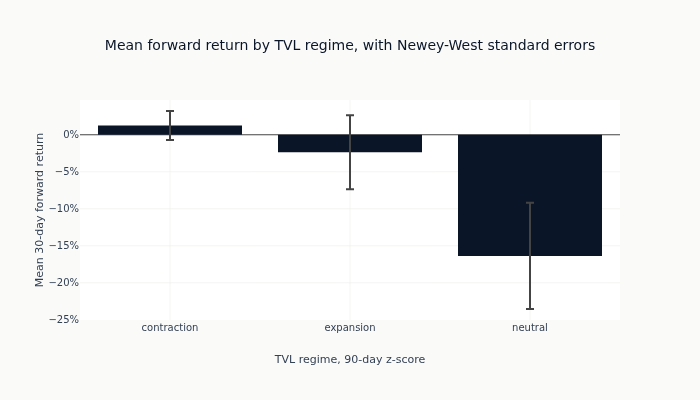

In [18]:
fig = px.bar(
    regime_means.to_pandas(),
    x="tvl_regime",
    y="mean_forward_return",
    error_y="standard_error",
    title="Mean forward return by TVL regime, with Newey-West standard errors",
    labels={
        "tvl_regime": f"TVL regime, {ZSCORE_DAYS}-day z-score",
        "mean_forward_return": f"Mean {FORWARD_DAYS}-day forward return",
    },
    color_discrete_sequence=[COLORS["blue"]],
)
fig.update_layout(height=400, yaxis_tickformat=".0%")
show_plotly_with_alt(
    fig,
    "Bar chart of the mean forward ether return in each TVL regime, with Newey-West standard "
    "errors as error bars. The regimes are the buckets the trailing TVL z-score falls into.",
)

Read the contrast table rather than the regime means. The hypothesis this section set out to
test is that TVL expansion precedes higher returns and contraction lower ones, so the quantity
that tests it is the contraction-against-expansion contrast, under the corrected covariance;
the estimates do not support it. The pattern across the three buckets is worth reading as well
as the statistics, because a bucket defined as carrying no signal is not where a monotonic
relationship in the z-score would put the extreme mean, in either direction. Noise partitioned
three ways is one explanation and this sample cannot separate it from another. The three
contrasts are also three tests on the handful of independent windows counted below, which is
not a setting in which one of them clearing a threshold means much.

### The same question as a regression

The linear version is a regression of the forward return on TVL growth. Its uncorrected
t-statistic assumes each daily observation is an independent draw, which the overlap makes
false; the Newey-West correction widens the standard error by the amount of serial dependence
actually present, and the lag is set one short of the horizon because that is how far the
overlap reaches.

In [19]:
signal = tested["tvl_growth"].to_numpy()
outcome = tested["forward_return"].to_numpy()
design = sm.add_constant(signal)

naive = sm.OLS(outcome, design).fit()
corrected = sm.OLS(outcome, design).fit(cov_type="HAC", cov_kwds={"maxlags": FORWARD_DAYS - 1})

print(
    f"Correlation between TVL growth and the forward return: {tested.select(pl.corr('tvl_growth', 'forward_return')).item():+.3f}"
)
print(f"Slope: {naive.params[1]:+.3f}")
print(f"t-statistic assuming independent days: {naive.tvalues[1]:+.2f}")
print(f"t-statistic with the overlap corrected: {corrected.tvalues[1]:+.2f}")
print(f"Independent thirty-day windows in the sample: {len(tested) / FORWARD_DAYS:.0f}")

Correlation between TVL growth and the forward return: +0.066
Slope: +0.108
t-statistic assuming independent days: +1.16
t-statistic with the overlap corrected: +0.48
Independent thirty-day windows in the sample: 10


The count on the last line is what the section turns on. A year of daily observations of a
forward return spanning a month is a handful of independent windows, not a year of them, and a
sample that size cannot establish a relationship of this magnitude whatever the daily row count
suggests.

**What binds is the price feed, not the TVL series.** DeFi Llama publishes the whole history of
the sector for free; the free price tier serves the trailing year. Extending the study needs a
longer price history, which the exchange feeds in Chapter 2 provide, and that is the change
that would make this question answerable rather than any refinement of the signal.

## Key Takeaways

1. Total value locked is a dollar-denominated stock of crypto assets, so it moves with the
   prices of those assets by construction. A test of whether it predicts price has to be built
   on growth or on a standardized level, never on the level itself.
2. Show a composition against the true total. Four chains plotted against each other will
   always fill the chart, whatever share of the market they actually hold.
3. Compute a forward return from the price at the two ends of the window. Shifting a trailing
   return only gives the forward return when the trailing window and the forward horizon are
   the same length, which makes the construction silently wrong the moment either is changed.
4. A forward return sampled daily over a thirty-day horizon gives thirty overlapping views of
   each window, so the row count is not the sample size. Correct for that with a Newey-West
   covariance at a lag as long as the overlap, rather than by dividing the row count, which
   assumes a dependence structure the data need not have.
5. A regime table with three buckets will always produce an ordering. Estimate the bucket means
   as coefficients on regime indicators under the same corrected covariance and put the
   standard errors on the chart. Then read the pattern as well as the statistics: where a
   bucket defined as "no signal" carries the extreme mean, that is what noise partitioned three
   ways looks like, whatever any one t-statistic says.
6. The binding constraint on an alternative-data study is often not the alternative data. Here
   the free TVL history spans the whole sector and the free price history the trailing year, so
   the price feed decides what can be concluded.

**Next**: [`11_defi_tvl_evaluation`](11_defi_tvl_evaluation.ipynb) applies the chapter's full
due-diligence framework - signal, quality, legal risk and cost - to this same dataset.